# Visual Prompt Tuning

In [ ]:
import torch.nn as nn
import torch
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd

In [ ]:
class EarlyStopper:
    def __init__(self, patience=3, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.min_validation_loss = np.inf

    def early_stop(self, validation_loss):
        if validation_loss <= self.min_validation_loss - self.min_delta:
            self.min_validation_loss = validation_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                return True
        return False

In [ ]:
class VisualPromptTuningResNet(nn.Module):
    def __init__(self, num_classes=102, prompt_size=30, prompt_type='additive'):
        super().__init__()

        # back
        self.backbone = models.resnet50(pretrained=True)
        self.feature_dim = self.backbone.fc.in_features

        # freeze backbone except for the final layers
        for name, param in self.backbone.named_parameters():
            if 'layer4' not in name and 'fc' not in name:
                param.requires_grad = False

        self.prompt_type = prompt_type
        if prompt_type == 'additive':
            self.prompts = nn.Parameter(torch.zeros(1, 3, prompt_size, prompt_size) * 0.01)
        elif prompt_type == 'patch':
            self.prompts = nn.Parameter(torch.zeros(1, 3, 16, 16) * 0.01)

        # classifier
        self.backbone.fc = nn.Linear(self.feature_dim, num_classes)

        # regularization
        self.dropout = nn.Dropout(0.2)

        print(f"Trainable params: {sum(p.numel() for p in self.parameters() if p.requires_grad):,}")
        print(f"Frozen params: {sum(p.numel() for p in self.parameters() if not p.requires_grad):,}")

    def add_prompts_to_input(self, x):
        batch_size = x.size(0)

        if self.prompt_type == 'additive':
            prompts_resized = F.interpolate(
                self.prompts.repeat(batch_size, 1, 1, 1),
                size=(x.size(2), x.size(3)),
                mode='bilinear',
                align_corners=False
            )
            prompted_x = x + 0.1 * prompts_resized
        else:
            prompted_x = x

        return prompted_x

    def forward(self, x):
        x = self.add_prompts_to_input(x)
        x = self.backbone(x)
        x = self.dropout(x)  # regularization
        return x


In [ ]:
def training():
    # data augmentation
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(0.3),
        transforms.RandomRotation(10),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    val_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    # reload datasets with augmentation
    train_dataset = datasets.Flowers102('data', split='train', download=True, transform=train_transform)
    val_dataset = datasets.Flowers102('data', split='val', download=True, transform=val_transform)

    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, drop_last=True)
    val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

    # model and optimizer
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = VisualPromptTuningResNet(num_classes=102, prompt_size=30, prompt_type='additive')
    model = model.to(device)

    # improved optimizer settings
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = optim.AdamW(trainable_params, lr=0.0001, weight_decay=0.01)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

    loss_fn = nn.CrossEntropyLoss()

    # training loop
    best_val_acc = 0
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(100):
        # training
        model.train()
        train_loss, train_correct = 0, 0
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)

            optimizer.zero_grad()
            pred = model(X)
            loss = loss_fn(pred, y)

            # gradient clipping
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss += loss.item()
            train_correct += (pred.argmax(1) == y).sum().item()

        # validation
        model.eval()
        val_loss, val_correct = 0, 0
        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(device), y.to(device)
                pred = model(X)
                val_loss += loss_fn(pred, y).item()
                val_correct += (pred.argmax(1) == y).sum().item()

        train_loss = train_loss / len(train_loader)
        train_acc = train_correct / len(train_dataset)
        val_loss = val_loss / len(val_loader)
        val_acc = val_correct / len(val_dataset)

        train_losses.append(train_loss)
        train_accs.append(train_acc)
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        scheduler.step()

        print(f"Epoch {epoch+1:3d}: "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc*100:.2f}% | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc*100:.2f}% | "
              f"LR: {scheduler.get_last_lr()[0]:.6f}")

        # early stopping
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= 10:
            print("Early stopping - no improvement")
            break

    return model, train_losses, train_accs, val_losses, val_accs

# training
model, train_losses, train_accs, val_losses, val_accs = training()

Trainable params: 15,176,434
Frozen params: 8,543,296
Epoch   1: Train Loss: 4.4607, Train Acc: 7.94% | Val Loss: 3.8991, Val Acc: 25.10% | LR: 0.000100
Epoch   2: Train Loss: 3.5676, Train Acc: 39.22% | Val Loss: 3.1076, Val Acc: 55.88% | LR: 0.000100
Epoch   3: Train Loss: 2.7580, Train Acc: 60.69% | Val Loss: 2.5463, Val Acc: 69.90% | LR: 0.000099
Epoch   4: Train Loss: 2.2610, Train Acc: 61.76% | Val Loss: 1.9543, Val Acc: 76.47% | LR: 0.000098
Epoch   5: Train Loss: 1.7406, Train Acc: 70.59% | Val Loss: 1.7990, Val Acc: 82.06% | LR: 0.000098
Epoch   6: Train Loss: 1.4113, Train Acc: 73.14% | Val Loss: 1.3819, Val Acc: 87.94% | LR: 0.000096
Epoch   7: Train Loss: 1.0553, Train Acc: 76.47% | Val Loss: 1.1822, Val Acc: 87.84% | LR: 0.000095
Epoch   8: Train Loss: 0.9709, Train Acc: 75.69% | Val Loss: 0.9644, Val Acc: 90.00% | LR: 0.000094
Epoch   9: Train Loss: 0.8987, Train Acc: 74.71% | Val Loss: 0.8335, Val Acc: 90.20% | LR: 0.000092
Epoch  10: Train Loss: 0.7917, Train Acc: 75.78

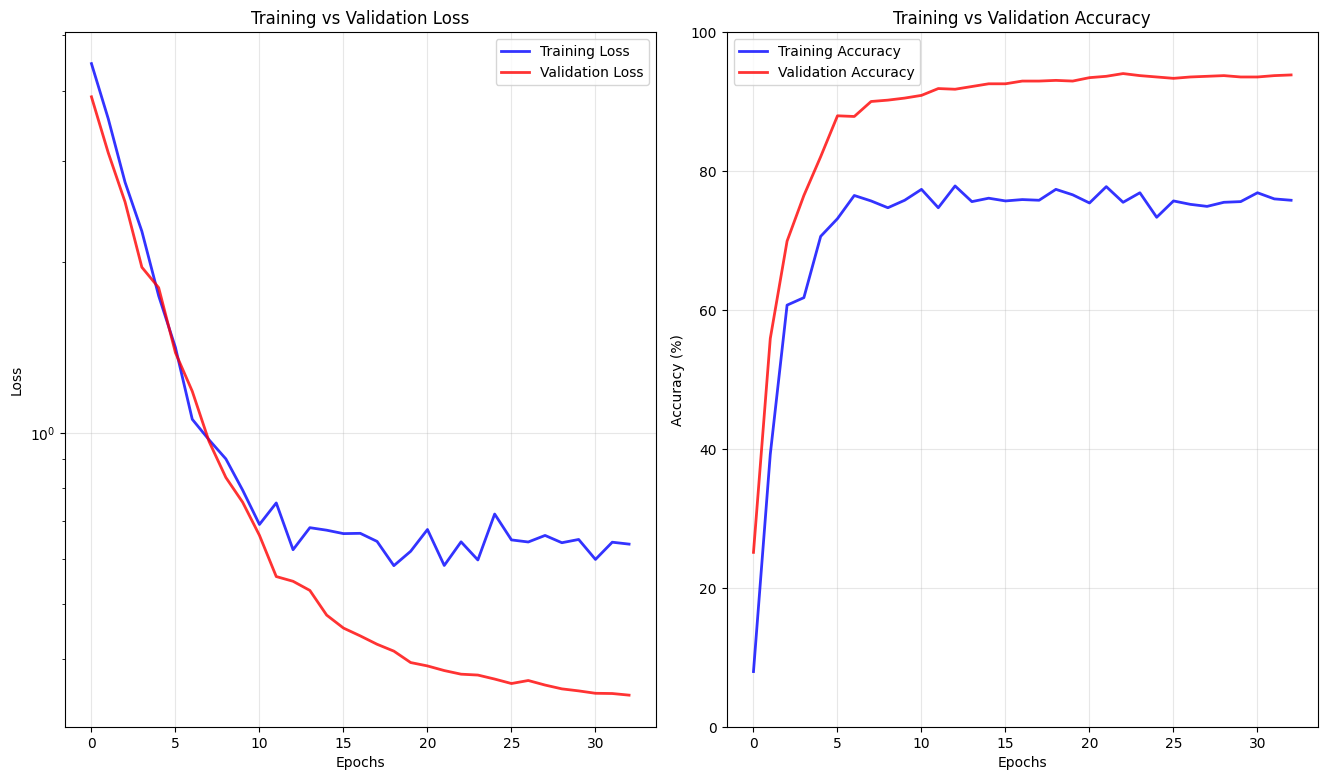

In [ ]:
plt.figure(figsize=(20, 15))

# loss curves
plt.subplot(2, 3, 1)
plt.plot(train_losses, 'b-', linewidth=2, label='Training Loss', alpha=0.8)
plt.plot(val_losses, 'r-', linewidth=2, label='Validation Loss', alpha=0.8)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')

# accuracy curves
plt.subplot(2, 3, 2)
plt.plot([acc * 100 for acc in train_accs], 'b-', linewidth=2, label='Training Accuracy', alpha=0.8)
plt.plot([acc * 100 for acc in val_accs], 'r-', linewidth=2, label='Validation Accuracy', alpha=0.8)
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

Evaluating on test dataset...

TEST RESULTS
Test Loss: 0.4246
Test Accuracy: 91.04%
Correct predictions: 5598/6149

Validation Accuracy (final): 93.82%
Test Accuracy: 91.04%
Generalization Gap: 2.78%

DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0     0.6897    1.0000    0.8163        20
           1     1.0000    1.0000    1.0000        40
           2     0.5714    0.6000    0.5854        20
           3     0.7692    0.5556    0.6452        36
           4     0.9512    0.8667    0.9070        45
           5     1.0000    0.9600    0.9796        25
           6     0.7308    0.9500    0.8261        20
           7     0.9848    1.0000    0.9924        65
           8     0.7576    0.9615    0.8475        26
           9     0.9615    1.0000    0.9804        25
          10     0.8689    0.7910    0.8281        67
          11     0.9420    0.9701    0.9559        67
          12     0.9667    1.0000    0.9831        29
          1

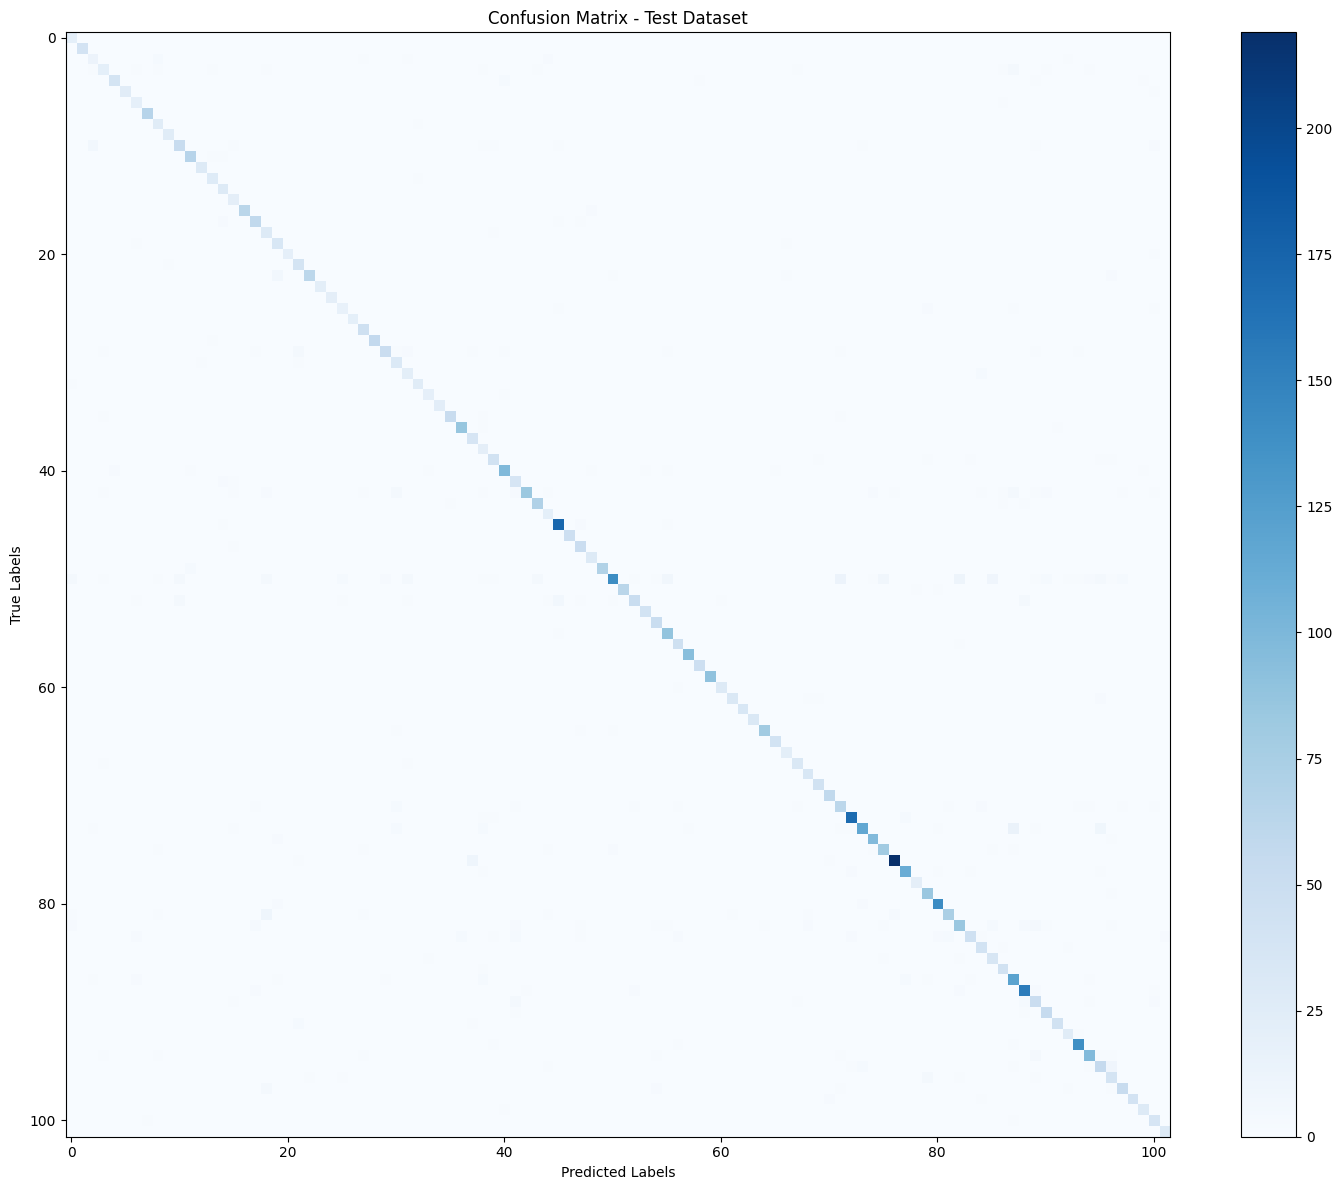

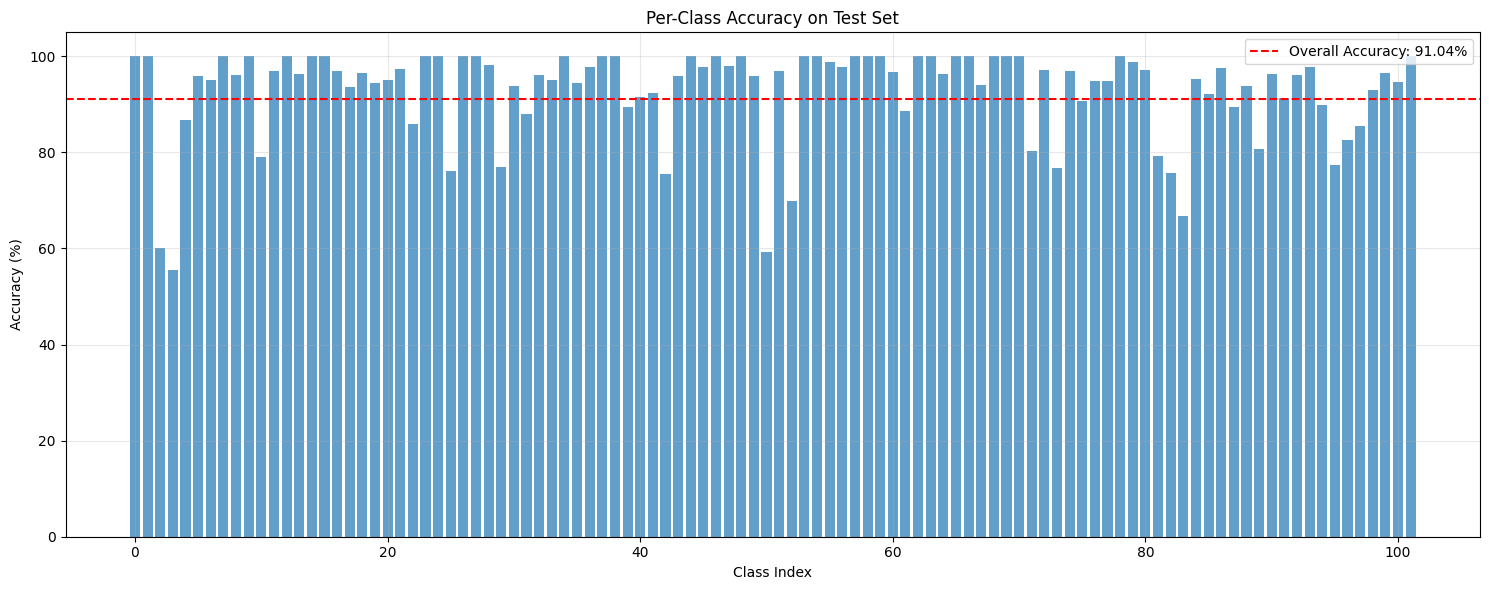


FINAL PERFORMANCE SUMMARY
✓ Best Validation Accuracy: 94.02%
✓ Final Validation Accuracy: 93.82%
✓ Test Accuracy: 91.04%
✓ Generalization: Good
✓ Training Epochs: 33
✓ Final Training Loss: 0.6362
✓ Final Validation Loss: 0.3450
✓ Test Loss: 0.4246


In [ ]:
def evaluate_on_test(model, test_loader, loss_fn):
    model.eval()
    device = next(model.parameters()).device

    test_loss = 0
    test_correct = 0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for X, y in test_loader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            loss = loss_fn(pred, y)

            test_loss += loss.item()
            test_correct += (pred.argmax(1) == y).sum().item()

            all_preds.extend(pred.argmax(1).cpu().numpy())
            all_targets.extend(y.cpu().numpy())

    test_loss /= len(test_loader)
    test_accuracy = test_correct / len(test_loader.dataset)

    return test_loss, test_accuracy, all_preds, all_targets

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_dataset = datasets.Flowers102('data', split='test', download=True, transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# evaluating on test set
print("Evaluating on test dataset...")
test_loss, test_accuracy, test_preds, test_targets = evaluate_on_test(model, test_loader, nn.CrossEntropyLoss())

print(f"\n{'='*50}")
print("TEST RESULTS")
print(f"{'='*50}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy*100:.2f}%")
print(f"Correct predictions: {int(test_accuracy * len(test_dataset))}/{len(test_dataset)}")

# compare with validation performance
final_val_accuracy = val_accs[-1]
print(f"\nValidation Accuracy (final): {final_val_accuracy*100:.2f}%")
print(f"Test Accuracy: {test_accuracy*100:.2f}%")
print(f"Generalization Gap: {abs(final_val_accuracy - test_accuracy)*100:.2f}%")

print(f"\n{'='*50}")
print("DETAILED CLASSIFICATION REPORT")
print(f"{'='*50}")
print(classification_report(test_targets, test_preds, digits=4))

# confusion matrix
plt.figure(figsize=(15, 12))
cm = confusion_matrix(test_targets, test_preds)
plt.imshow(cm, cmap='Blues', interpolation='nearest')
plt.colorbar()
plt.title('Confusion Matrix - Test Dataset')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.tight_layout()
plt.show()

# per-class accuracy
class_accuracy = cm.diagonal() / cm.sum(axis=1)
plt.figure(figsize=(15, 6))
plt.bar(range(len(class_accuracy)), class_accuracy * 100, alpha=0.7)
plt.xlabel('Class Index')
plt.ylabel('Accuracy (%)')
plt.title('Per-Class Accuracy on Test Set')
plt.axhline(y=test_accuracy*100, color='r', linestyle='--', label=f'Overall Accuracy: {test_accuracy*100:.2f}%')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# final performance summary
print(f"\n{'='*50}")
print("FINAL PERFORMANCE SUMMARY")
print(f"{'='*50}")
print(f"✓ Best Validation Accuracy: {max(val_accs)*100:.2f}%")
print(f"✓ Final Validation Accuracy: {val_accs[-1]*100:.2f}%")
print(f"✓ Test Accuracy: {test_accuracy*100:.2f}%")
print(f"✓ Generalization: {'Good' if abs(val_accs[-1] - test_accuracy) < 0.05 else 'Potential overfitting'}")
print(f"✓ Training Epochs: {len(train_accs)}")
print(f"✓ Final Training Loss: {train_losses[-1]:.4f}")
print(f"✓ Final Validation Loss: {val_losses[-1]:.4f}")
print(f"✓ Test Loss: {test_loss:.4f}")